In [ ]:
# --- Arranque del entorno local (en Google Colab no cambia nada) ---
import pathlib
import sys
import types

try:
    _raiz = next(
        d
        for d in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
        if (d / "curso_setup.py").exists()
    )
    sys.path.insert(0, str(_raiz))
    import curso_setup
except StopIteration:  # Google Colab: se usa un sustituto mínimo
    import subprocess

    def _clonar(destino="curso_IA_CHEC"):
        if not pathlib.Path(destino).is_dir():
            subprocess.run(
                ["git", "clone", "https://github.com/UN-GCPDS/curso_IA_CHEC.git", destino],
                check=True,
            )
        return pathlib.Path(destino)

    def _descargar(file_id, destino):
        if not pathlib.Path(destino).exists():
            import gdown

            gdown.download(id=file_id, output=destino, quiet=False)
        return pathlib.Path(destino)

    curso_setup = types.SimpleNamespace(
        en_colab=lambda: True,
        init=lambda *a, **k: pathlib.Path.cwd(),
        clonar_curso=_clonar,
        descargar_drive=_descargar,
    )

curso_setup.init()

# **Práctica: Procesamiento de datos**

Se abordarán los principios de programación para el manejo de datos desde Python. Además, se estudiarán algunas herramientas para el análisis exploratorio de datos como apoyo a la toma de decisiones informadas.

# Configuración del entorno de trabajo

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Descripción de la base de datos

La base de datos [*titanic* ](https://www.kaggle.com/datasets/brendan45774/test-file)contiene información sobre los pasajeros del RMS Titanic, un transatlántico que naufragó en 1912 tras chocar contra un iceberg.  A continuación se hace una pequeña descripción de cada variable (columna):

* PassengerId: 	Identificador único del pasajero.
* Survived:	Variable objetivo: indica si el pasajero sobrevivió (1) o no (0).
* Pclass:	Clase del boleto (1 = Primera clase, 2 = Segunda clase, 3 = Tercera clase).
* Name:	Nombre del pasajero.
* Sex:	Género del pasajero (male = hombre, female = mujer)
* Age:	Edad del pasajero (en años, algunos valores son faltantes).
* SibSp:	Número de hermanos/esposos a bordo.
* Parch:	Número de padres/hijos a bordo.
* Ticket:	Número del boleto.
* Fare:	Tarifa del boleto (en libras esterlinas).
* Cabin:	Número de cabina (valores faltantes para muchos pasajeros).
* Embarked:	Puerto de embarque (C = Cherbourg, Q = Queenstown, S = Southampton).

In [ ]:
import kagglehub
import pandas as pd

# Descargar el dataset
path = kagglehub.dataset_download("brendan45774/test-file")
print("Path to dataset files:", path)

# Cargar el archivo en Pandas
file_path = f"{path}/tested.csv"  # Ajusta "test.csv" si el archivo tiene otro nombre
titanic = pd.read_csv(file_path)

100%|██████████| 11.2k/11.2k [00:00<00:00, 5.25MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/brendan45774/test-file/versions/6


# **Análisis exploratorio inicial**

## **Primeras filas del dataset con `.head()`**

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Crear un Output widget para controlar la salida
output = widgets.Output()

# Crear un deslizante para seleccionar el número de filas
slider = widgets.IntSlider(
    value=5,  # Valor inicial
    min=0,    # Valor mínimo
    max=20,   # Valor máximo
    step=1,   # Incremento
    description='Filas:',
    continuous_update=False  # Actualiza solo al soltar el control
)

# Función para mostrar las primeras filas
def mostrar_filas(cambio):
    with output:
        clear_output(wait=True)  # Limpia la salida previa
        num_filas = slider.value
        print(f"Mostrando las primeras {num_filas} filas del DataFrame:")
        display(titanic.head(num_filas))  # Asume que 'titanic' ya está definido

# Conectar el slider a la función
slider.observe(mostrar_filas, names='value')

# Mostrar widgets y área de salida
display(slider, output)


IntSlider(value=5, continuous_update=False, description='Filas:', max=20)

Output()

## **Información general del dataset con `.info()`**

La función .info() nos da un resumen del dataset, incluyendo el número de entradas, los tipos de datos de cada columna y la cantidad de valores nulos. Esto es muy útil para entender la estructura de los datos y posibles problemas de calidad (como valores faltantes).


In [ ]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [ ]:
# @title **Pregunta 1**

num_registros = len(titanic)  # Número de filas en el DataFrame

# Crear widgets para la pregunta
pregunta2 = widgets.Label(value="¿Cuántos registros tiene la base de datos?")
respuesta2 = widgets.IntText(description="Respuesta:", placeholder="Escribe un número")
boton2 = widgets.Button(description="Verificar")
output2 = widgets.Output()

# Función para verificar la respuesta
def verificar_respuesta2(b):
    with output2:
        clear_output(wait=True)  # Limpia la salida previa
        if respuesta2.value == num_registros:
            print("✅ ¡Correcto!")
        else:
            print(f"❌ Incorrecto. Esta información se encuentra al principio de .info()")

# Conectar el botón a la función
boton2.on_click(verificar_respuesta2)

# Mostrar widgets
display(pregunta2, respuesta2, boton2, output2)

Label(value='¿Cuántos registros tiene la base de datos?')

IntText(value=0, description='Respuesta:')

Button(description='Verificar', style=ButtonStyle())

Output()

In [ ]:
# @title **Pregunta 2**

missing_cabin = titanic['Cabin'].isnull().sum()  # Ajusta si el nombre está en mayúsculas/minúsculas

# Crear widgets para la pregunta
pregunta = widgets.Label(value="¿Cuántos valores faltantes hay en la columna 'Cabin'?")
respuesta = widgets.IntText(description="Respuesta:", placeholder="Escribe un número")
boton = widgets.Button(description="Verificar")
output = widgets.Output()

# Función para verificar la respuesta
def verificar_respuesta(b):
    with output:
        clear_output(wait=True)  # Limpia la salida previa
        if respuesta.value == missing_cabin:
            print("✅ ¡Correcto!")
        else:
            print(f"❌ Incorrecto. La respuesta correcta de calcula restando el número de entradas no nulas del valor total de entradas.")

# Conectar el botón a la función
boton.on_click(verificar_respuesta)

# Mostrar widgets
display(pregunta, respuesta, boton, output)


Label(value="¿Cuántos valores faltantes hay en la columna 'Cabin'?")

IntText(value=0, description='Respuesta:')

Button(description='Verificar', style=ButtonStyle())

Output()

## **Análisis de Frecuencia con `.value_counts()`**

La función .value_counts() es útil para analizar la frecuencia de los valores en una columna específica.

In [ ]:
# @title Explora las frecuencias de las diferentes columnas

# Crear un Output widget para controlar la salida
output = widgets.Output()

# Crear un menú desplegable con las columnas del DataFrame 'titanic'
dropdown_columnas = widgets.Dropdown(
    options=titanic.columns.tolist(),  # Lista de las columnas de 'titanic'
    description='Seleccionar columna:',
    disabled=False
)

# Función para mostrar los value_counts() de la columna seleccionada
def mostrar_value_counts(change):
    with output:
        clear_output(wait=True)  # Limpia la salida previa
        columna_seleccionada = dropdown_columnas.value
        print(f"Mostrando .value_counts() para la columna '{columna_seleccionada}':")
        display(titanic[columna_seleccionada].value_counts())

# Conectar el dropdown a la función
dropdown_columnas.observe(mostrar_value_counts, names='value')

# Mostrar widgets y área de salida
display(dropdown_columnas, output)

Dropdown(description='Seleccionar columna:', options=('PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age…

Output()

In [ ]:
# @title **Pregunta 3**
# Calcular el valor más frecuente de la columna "Embarked"
valor_frecuente_embarked = titanic['Embarked'].mode()[0]  # El valor más frecuente (modo)

# Crear widgets para la pregunta
pregunta_embarked = widgets.Label(value="¿Cuál es el valor más frecuente en la columna 'Embarked'?")
respuesta_embarked = widgets.Text(description="Respuesta:", placeholder="Escribe el valor")
boton_embarked = widgets.Button(description="Verificar")
output_embarked = widgets.Output()

# Función para verificar la respuesta
def verificar_respuesta_embarked(b):
    with output_embarked:
        clear_output(wait=True)  # Limpia la salida previa
        if respuesta_embarked.value.lower() == valor_frecuente_embarked.lower():
            print("✅ ¡Correcto!")
        else:
            print(f"❌ Incorrecto. Verifica nuevamente, escribe el nombre exacto de la clase.")

# Conectar el botón a la función
boton_embarked.on_click(verificar_respuesta_embarked)

# Mostrar widgets
display(pregunta_embarked, respuesta_embarked, boton_embarked, output_embarked)

Label(value="¿Cuál es el valor más frecuente en la columna 'Embarked'?")

Text(value='', description='Respuesta:', placeholder='Escribe el valor')

Button(description='Verificar', style=ButtonStyle())

Output()

## **Indexación básica**

Recuerda que podemos elegir solo ver algunas filas o columnas dependiendo de la tarea en la que estemos interesados en ese momento.

In [ ]:
# @title Selecciona las columnas que sean de tu interés

# Crear un Output widget para controlar la salida
output = widgets.Output()

# Crear los checkboxes para cada columna del DataFrame 'titanic'
checkboxes = [widgets.Checkbox(value=True, description=col) for col in titanic.columns]

# Crear un botón para ejecutar
boton_ejecutar = widgets.Button(description="Ejecutar")

# Función para mostrar los primeros 5 registros de las columnas seleccionadas
def mostrar_columnas_seleccionadas(b):
    with output:
        clear_output(wait=True)  # Limpia la salida previa
        # Filtrar las columnas seleccionadas
        columnas_seleccionadas = [checkbox.description for checkbox in checkboxes if checkbox.value]
        # Mostrar las primeras 5 filas de las columnas seleccionadas
        display(titanic[columnas_seleccionadas].head())

# Conectar el botón a la función
boton_ejecutar.on_click(mostrar_columnas_seleccionadas)

# Mostrar widgets y área de salida
display(widgets.VBox(checkboxes), boton_ejecutar, output)

Button(description='Ejecutar', style=ButtonStyle())

Output()

In [ ]:
# @title Selecciona el índice de la fila de un pasajero que quieras conocer su nombre, edad y género

# Crear un Output widget para controlar la salida
output = widgets.Output()

# Crear la entrada interactiva para escribir el número de fila
entrada_fila = widgets.IntText(
    value=0,  # Valor inicial
    description="Número de fila:",
    min=0,  # Valor mínimo
    max=len(titanic)-1,  # Número máximo de fila (basado en la longitud del DataFrame)
    step=1,  # Incremento
    style={'description_width': 'initial'}
)

# Crear un botón de "Ejecutar"
boton_ejecutar = widgets.Button(description="Ejecutar")

# Función para mostrar la fila seleccionada
def mostrar_fila(b):
    with output:
        clear_output(wait=True)  # Limpia la salida previa
        num_fila = entrada_fila.value
        if num_fila >= 0 and num_fila < len(titanic):
            print(f"Fila número {num_fila}:")
            print(titanic.iloc[num_fila][['Name', 'Age', 'Sex']])
        else:
            print(f"❌ Número de fila fuera de rango. Intenta con un número entre 0 y {len(titanic)-1}.")

# Conectar el botón a la función
boton_ejecutar.on_click(mostrar_fila)

# Mostrar widgets y área de salida
display(entrada_fila, boton_ejecutar, output)


IntText(value=0, description='Número de fila:', style=DescriptionStyle(description_width='initial'))

Button(description='Ejecutar', style=ButtonStyle())

Output()

In [ ]:
# @title **Pregunta 4**

# Obtener el género del pasajero en el índice 318
genero_318 = titanic.iloc[318]['Sex']  # Asumiendo que la columna de género es 'sex'

# Crear widgets para la pregunta
pregunta_318 = widgets.Label(value="¿Cuál es el género del pasajero en el índice 318?")
respuesta_318 = widgets.Text(description="Respuesta:", placeholder="Escribe 'male' o 'female'")
boton_318 = widgets.Button(description="Verificar")
output_318 = widgets.Output()

# Función para verificar la respuesta
def verificar_respuesta_318(b):
    with output_318:
        clear_output(wait=True)  # Limpia la salida previa
        if respuesta_318.value.lower() == genero_318.lower():
            display("✅ ¡Correcto!")
        else:
            display(f"❌ Incorrecto.")

# Conectar el botón a la función
boton_318.on_click(verificar_respuesta_318)

# Mostrar widgets
display(pregunta_318, respuesta_318, boton_318, output_318)


Label(value='¿Cuál es el género del pasajero en el índice 318?')

Text(value='', description='Respuesta:', placeholder="Escribe 'male' o 'female'")

Button(description='Verificar', style=ButtonStyle())

Output()

## **Estadística Básica con `.describe()`**

Genera las estadístibas básicas de las columnas (variables de interés). Las estadísticas descriptivas incluyen aquellas que resumen la tendencia central, la dispersión y la forma de la distribución de un conjunto de datos, excluyendo los valores faltantes.

In [ ]:
# @title **Selecciona la columna para conocer su estadística básica**

# Crear un Output widget para controlar la salida
output = widgets.Output()

# Crear el menú desplegable con las columnas del DataFrame 'titanic'
dropdown_columnas = widgets.Dropdown(
    options=titanic.columns.tolist(),  # Lista de las columnas de 'titanic'
    description='Seleccionar columna:',
    disabled=False
)

# Función para mostrar el resumen estadístico de la columna seleccionada
def mostrar_describe(change):
    with output:
        clear_output(wait=True)  # Limpia la salida previa
        columna_seleccionada = dropdown_columnas.value
        print(f"Mostrando resumen estadístico (describe) para la columna '{columna_seleccionada}':")
        display(titanic[columna_seleccionada].describe())

# Conectar el dropdown a la función
dropdown_columnas.observe(mostrar_describe, names='value')

# Mostrar widgets y área de salida
display(dropdown_columnas, output)

Dropdown(description='Seleccionar columna:', options=('PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age…

Output()

In [ ]:
# @title **Pregunta 5**

# Obtener el valor máximo de la columna 'age'
max_edad = titanic['Age'].max()

# Crear widgets para la pregunta
pregunta_edad = widgets.Label(value="¿Cuál es el valor máximo de la edad en el DataFrame?")
respuesta_edad = widgets.IntText(description="Respuesta:", placeholder="Escribe el valor")
boton_edad = widgets.Button(description="Verificar")
output_edad = widgets.Output()

# Función para verificar la respuesta
def verificar_respuesta_edad(b):
    with output_edad:
        clear_output(wait=True)  # Limpia la salida previa
        if respuesta_edad.value == max_edad:
            print("✅ ¡Correcto!")
        else:
            print(f"❌ Incorrecto. Verifica nuevamente.")

# Conectar el botón a la función
boton_edad.on_click(verificar_respuesta_edad)

# Mostrar widgets
display(pregunta_edad, respuesta_edad, boton_edad, output_edad)

Label(value='¿Cuál es el valor máximo de la edad en el DataFrame?')

IntText(value=0, description='Respuesta:')

Button(description='Verificar', style=ButtonStyle())

Output()

## **Correlación**

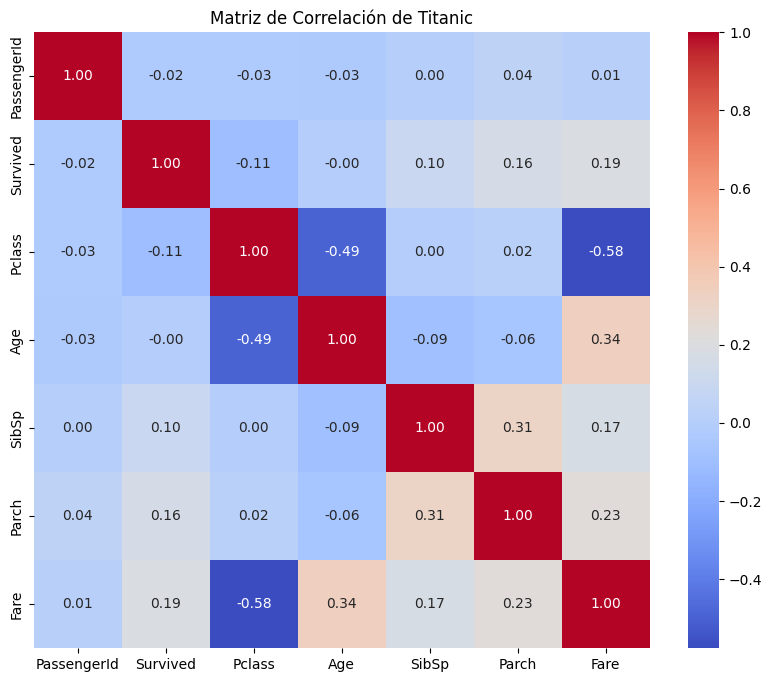

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrar solo las columnas numéricas
titanic_num = titanic.select_dtypes(include=['float64', 'int64'])

# Calcular la matriz de correlación
correlacion = titanic_num.corr()

# Configuración de la gráfica
plt.figure(figsize=(10, 8))  # Tamaño de la figura
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt='.2f', cbar=True, square=True)

# Título de la gráfica
plt.title('Matriz de Correlación de Titanic')

# Mostrar la gráfica
plt.show()

In [ ]:
# @title **Pregunta 6**

# Filtrar solo las columnas numéricas
titanic_num = titanic.select_dtypes(include=['float64', 'int64'])

# Calcular la matriz de correlación
correlacion = titanic_num.corr()

# Encontrar las dos variables más correlacionadas (positiva o negativa)
correlacion_desapilada = correlacion.where(~correlacion.isnull()).stack()
correlacion_desapilada = correlacion_desapilada[correlacion_desapilada != 1]  # Excluir correlaciones consigo mismas
var_mas_correlacionadas = correlacion_desapilada.idxmax()  # Variables con mayor correlación absoluta

# Crear los widgets
pregunta = widgets.Label(value="Selecciona las dos variables que tienen la correlación positiva más fuerte:")
checkboxes = {col: widgets.Checkbox(value=False, description=col) for col in titanic_num.columns}
boton_verificar = widgets.Button(description="Verificar")
output = widgets.Output()

# Función para verificar la respuesta
def verificar_respuesta(b):
    with output:
        clear_output(wait=True)
        seleccionadas = [col for col, checkbox in checkboxes.items() if checkbox.value]
        if set(seleccionadas) == set(var_mas_correlacionadas):
            print("✅ ¡Correcto! Las variables más correlacionadas son: {}.".format(var_mas_correlacionadas))
        else:
            print(f"❌ Incorrecto. Verifica nuevamente.")

# Conectar el botón a la función
boton_verificar.on_click(verificar_respuesta)

# Mostrar los widgets
display(pregunta)
for checkbox in checkboxes.values():
    display(checkbox)
display(boton_verificar, output)

Label(value='Selecciona las dos variables que tienen la correlación positiva más fuerte:')

Checkbox(value=False, description='PassengerId')

Checkbox(value=False, description='Survived')

Checkbox(value=False, description='Pclass')

Checkbox(value=False, description='Age')

Checkbox(value=False, description='SibSp')

Checkbox(value=False, description='Parch')

Checkbox(value=False, description='Fare')

Button(description='Verificar', style=ButtonStyle())

Output()

# **Ejercicio 1**

## **Imputación y eliminación de datos**

Notamos en la exploración inicial que las tres columnas con valores faltantes son 'Cabin', 'Age' y 'Fare'.

In [ ]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


Desde tu punto de vista, escoge qué hacer con cada columna.

1. **Eliminar la fila o la columna con valores faltantes**
   - **Ventajas**: Es una estrategia simple y directa, útil cuando los valores faltantes son pocos y no representan una gran proporción de los datos.
   - **Desventajas**: Si hay muchos valores faltantes, eliminar demasiadas filas o columnas puede reducir significativamente el tamaño del conjunto de datos y hacer que pierdas información importante.

2. **Rellenar los valores faltantes con una constante**
   - **Ventajas**: Esta técnica es muy útil cuando quieres mantener la estructura del conjunto de datos sin perder filas o columnas. Una constante como 0 o la media de los valores puede ser utilizada como reemplazo.
   - **Desventajas**: El uso de una constante puede introducir sesgos si los valores faltantes no son aleatorios. También puede distorsionar la distribución de los datos.

3. **Rellenar con la media o la mediana** (`SimpleImputer` de `sklearn`)
   - **Ventajas**: Rellenar con la **media** (para datos numéricos) o la **mediana** es una estrategia común que mantiene el tamaño del conjunto de datos y evita eliminar información. Es especialmente útil cuando los valores faltantes no siguen un patrón claro.
   - **Desventajas**: Este método puede suavizar la variabilidad de los datos. Si hay muchos valores faltantes, la media o la mediana podrían no reflejar adecuadamente la naturaleza de los datos.

4. **Rellenar con el valor más frecuente** (`SimpleImputer` con `strategy='most_frequent'`)
   - **Ventajas**: Funciona bien en el caso de datos categóricos. Mantiene la consistencia al reemplazar los valores faltantes con la categoría más común.
   - **Desventajas**: Si los datos son desbalanceados, este enfoque puede reforzar el sesgo hacia la categoría dominante.

5. **Rellenar con interpolación o usando modelos predictivos** (`KNNImputer` o `IterativeImputer`)
   - **Ventajas**: Utilizando técnicas avanzadas, como la **interpolación** o el uso de **vecinos cercanos (KNN)**, se pueden predecir los valores faltantes basándose en otros valores del conjunto de datos. Esto suele generar mejores resultados cuando los valores faltantes son significativos o siguen un patrón complejo.
   - **Desventajas**: Estos métodos son más lentos y computacionalmente costosos. Además, pueden introducir complejidad innecesaria si los datos no tienen una relación clara que se pueda modelar bien.


In [ ]:
# @title Elige una estrategia para cada columna

from sklearn.impute import KNNImputer

# Copiar el DataFrame para evitar modificar el original
titanic_copy = titanic.copy()
df_2 = titanic_copy  # alias: el resto del cuaderno se refiere a df_2

# Estrategias disponibles
estrategias = ['Media', 'Mediana', 'Moda', 'Eliminar filas', 'Eliminar columna', 'KNN Imputación']

# Crear widgets para seleccionar estrategias
fare_strategy = widgets.Dropdown(
    options=estrategias,
    description='Fare:',
    value='Media'
)
age_strategy = widgets.Dropdown(
    options=estrategias,
    description='Age:',
    value='Media'
)
cabin_strategy = widgets.Dropdown(
    options=estrategias,
    description='Cabin:',
    value='Media'
)

# Botón para aplicar las estrategias
boton_aplicar = widgets.Button(description="Aplicar estrategias")
output = widgets.Output()

# Función para aplicar las estrategias seleccionadas
def aplicar_estrategias(b):
    global df_2
    with output:
        clear_output(wait=True)
        df_2 = titanic_copy.copy()  # Trabajar sobre una copia del DataFrame

        # Imputador KNN (se aplicará solo si es seleccionado)
        knn_imputer = KNNImputer(n_neighbors=5)

        # Aplicar estrategia para 'Fare'
        if fare_strategy.value == 'Media':
            df_2['Fare'].fillna(df_2['Fare'].mean(), inplace=True)
        elif fare_strategy.value == 'Mediana':
            df_2['Fare'].fillna(df_2['Fare'].median(), inplace=True)
        elif fare_strategy.value == 'Moda':
            df_2['Fare'].fillna(df_2['Fare'].mode()[0], inplace=True)
        elif fare_strategy.value == 'Eliminar filas':
            df_2.dropna(subset=['Fare'], inplace=True)
        elif fare_strategy.value == 'Eliminar columna':
            df_2.drop(columns=['Fare'], inplace=True)
        elif fare_strategy.value == 'KNN Imputación':
            df_2[['Fare']] = knn_imputer.fit_transform(df_2[['Fare']])

        # Aplicar estrategia para 'Age'
        if age_strategy.value == 'Media':
            df_2['Age'].fillna(df_2['Age'].mean(), inplace=True)
        elif age_strategy.value == 'Mediana':
            df_2['Age'].fillna(df_2['Age'].median(), inplace=True)
        elif age_strategy.value == 'Moda':
            df_2['Age'].fillna(df_2['Age'].mode()[0], inplace=True)
        elif age_strategy.value == 'Eliminar filas':
            df_2.dropna(subset=['Age'], inplace=True)
        elif age_strategy.value == 'Eliminar columna':
            df_2.drop(columns=['Age'], inplace=True)
        elif age_strategy.value == 'KNN Imputación':
            df_2[['Age']] = knn_imputer.fit_transform(df_2[['Age']])

        # Aplicar estrategia para 'Cabin'
        if cabin_strategy.value == 'Media' or cabin_strategy.value == 'Mediana':
            print("❌ La estrategia seleccionada no es válida para 'Cabin' porque la variable no es numérica.")
            return
        elif cabin_strategy.value == 'Moda':
            df_2['Cabin'].fillna(df_2['Cabin'].mode()[0], inplace=True)
        elif cabin_strategy.value == 'Eliminar filas':
            df_2.dropna(subset=['Cabin'], inplace=True)
        elif cabin_strategy.value == 'Eliminar columna':
            df_2.drop(columns=['Cabin'], inplace=True)
        elif cabin_strategy.value == 'KNN Imputación':
            # Cabin tiene muchos valores únicos, simplificaremos usando un reemplazo categórico
            df_2['Cabin'] = df_2['Cabin'].str[0]  # Usar solo la primera letra de Cabin
            df_2['Cabin'] = df_2['Cabin'].fillna('U')  # Rellenar NaN con una categoría ficticia

        # Mostrar el DataFrame resultante
        print("DataFrame resultante:")
        display(df_2.info())
        display(df_2.head())

# Conectar el botón a la función
boton_aplicar.on_click(aplicar_estrategias)

# Mostrar widgets
display(widgets.VBox([fare_strategy, age_strategy, cabin_strategy, boton_aplicar, output]))

## **Codificación de variables categóricas**

Recordemos el nombre de las columnas que son categóricas

In [ ]:
# Identificar las columnas categóricas
categorical_cols = df_2.select_dtypes(include=['object']).columns

# Imprimir los nombres de las variables categóricas
print("Variables categóricas en el dataset:")
for col in categorical_cols:
    print(f"- {col}")


Variables categóricas en el dataset:
- Name
- Sex
- Ticket
- Cabin
- Embarked


Las columnas Ticket, Cabin y Name en el dataset Titanic son prácticamente únicas para cada pasajero, lo que implica que contienen información que puede no ser útil para modelos predictivos o análisis generalizados así que las descartaremos.

In [ ]:
# Lista de columnas que queremos descartar si existen
columns_to_drop = ['Ticket', 'Cabin', 'Name']

# Verificar y descartar las columnas solo si están presentes en el DataFrame
titanic_filtered = df_2.drop(columns=[col for col in columns_to_drop if col in df_2.columns])

# Verificar las columnas restantes
print("Columnas restantes en el nuevo dataset:")
print(titanic_filtered.columns)

# Mostrar las primeras filas del nuevo dataset
titanic_filtered.head()


Columnas restantes en el nuevo dataset:
Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare', 'Embarked'],
      dtype='object')


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,892,0,3,male,34.5,0,0,7.8292,Q
1,893,1,3,female,47.0,1,0,7.0000,S
2,894,0,2,male,62.0,0,0,9.6875,Q
3,895,0,3,male,27.0,0,0,8.6625,S
4,896,1,3,female,22.0,1,1,12.2875,S


In [ ]:
# @title Selecciona cuál estrategia de codificación usar las columnas categóricas

import numpy as np
import pandas as pd
from ipywidgets import interact, Dropdown
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# Clase que manejará los datos y aplicará las estrategias de codificación
class CategoricalEncodingVisualizer:
    def __init__(self, data):
        self.original_data = data  # Guardar el DataFrame original
        self.categorical_cols = data.select_dtypes(include=['object']).columns  # Columnas categóricas
        self.last_encoded_data = None  # Para almacenar los datos codificados

    def apply_encoding(self, strategy):
        """Aplica la estrategia de codificación seleccionada y devuelve una copia codificada."""
        data_copy = self.original_data.copy()

        if not len(self.categorical_cols):
            print("No hay columnas categóricas en los datos.")
            return data_copy

        if strategy == 'Ordinal Encoder':
            encoder = OrdinalEncoder()
            data_copy[self.categorical_cols] = encoder.fit_transform(data_copy[self.categorical_cols])
        elif strategy == 'OneHot Encoder':
            encoder = OneHotEncoder(sparse_output=False)
            encoded_data = pd.DataFrame(encoder.fit_transform(data_copy[self.categorical_cols]),
                                        columns=encoder.get_feature_names_out(self.categorical_cols),
                                        index=data_copy.index)
            data_copy = data_copy.drop(self.categorical_cols, axis=1)
            data_copy = pd.concat([data_copy, encoded_data], axis=1)
        else:
            raise ValueError(f"Estrategia desconocida: {strategy}")

        # Guardar la última transformación
        self.last_encoded_data = data_copy
        return data_copy

    def get_last_encoded_data(self):
        """Devuelve los datos codificados de la última transformación."""
        if self.last_encoded_data is not None:
            return self.last_encoded_data
        else:
            print("No se ha aplicado ninguna codificación todavía.")
            return None

    def show_encoded_data(self, strategy):
        """Muestra una vista previa de los datos codificados usando la estrategia seleccionada."""
        global encoded_data
        try:
            print(f"\nVista previa de los datos codificados usando '{strategy}':\n")
            encoded_data = self.apply_encoding(strategy)
            display(encoded_data.info())
            display(encoded_data.head())
        except Exception as e:
            print(f"Error al aplicar la estrategia '{strategy}': {e}")

# Inicializar la clase con el DataFrame cargado (titanic_filtered)
visualizer = CategoricalEncodingVisualizer(titanic_filtered)

# Crear la función interactiva para seleccionar la estrategia de codificación
def interactive_encoding(strategy):
    visualizer.show_encoded_data(strategy)

# Hacer interactiva la selección de la estrategia de codificación
interact(interactive_encoding,
         strategy=Dropdown(options=['Ordinal Encoder',
                                    'OneHot Encoder'],
                           description='Estrategia de Encoding:', value='Ordinal Encoder'));

interactive(children=(Dropdown(description='Estrategia de Encoding:', options=('Ordinal Encoder', 'OneHot Enco…

## **Estandarización de los datos**

In [ ]:
# @title Escoge cuál estrategia utilizar
from ipywidgets import interact, Dropdown
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Clase que manejará los datos y aplicará las estrategias de escalado
class DataScalingVisualizer:
    def __init__(self, data):
        self.original_data = data  # Guardar el DataFrame original
        self.numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns  # Columnas numéricas
        self.last_scaled_data = None  # Para almacenar los datos escalados

    def apply_scaling(self, strategy):
        """Aplica la estrategia de escalado seleccionada y devuelve una copia escalada."""
        data_copy = self.original_data.copy()

        if not len(self.numeric_cols):
            print("No hay columnas numéricas en los datos.")
            return data_copy

        if strategy == 'Standard Scaler':
            scaler = StandardScaler()
            data_copy[self.numeric_cols] = scaler.fit_transform(data_copy[self.numeric_cols])
        elif strategy == 'MinMax Scaler':
            scaler = MinMaxScaler()
            data_copy[self.numeric_cols] = scaler.fit_transform(data_copy[self.numeric_cols])
        elif strategy == 'Robust Scaler':
            scaler = RobustScaler()
            data_copy[self.numeric_cols] = scaler.fit_transform(data_copy[self.numeric_cols])
        else:
            raise ValueError(f"Estrategia desconocida: {strategy}")

        # Guardar la última transformación
        self.last_scaled_data = data_copy
        return data_copy

    def get_last_scaled_data(self):
        """Devuelve los datos escalados de la última transformación."""
        if self.last_scaled_data is not None:
            return self.last_scaled_data
        else:
            print("No se ha aplicado ningún escalado todavía.")
            return None

    def show_scaled_data(self, strategy):
        """Muestra una vista previa de los datos escalados usando la estrategia seleccionada."""
        try:
            print(f"\nVista previa de los datos escalados usando '{strategy}':\n")
            scaled_data = self.apply_scaling(strategy)
            display(scaled_data.head())
        except Exception as e:
            print(f"Error al aplicar la estrategia '{strategy}': {e}")

# Inicializar la clase con el DataFrame cargado (encoded_data)
scaler_visualizer = DataScalingVisualizer(encoded_data)

# Crear la función interactiva para seleccionar la estrategia de escalado
def interactive_scaling(strategy):
    scaler_visualizer.show_scaled_data(strategy)

# Hacer interactiva la selección de la estrategia de escalado
interact(interactive_scaling,
         strategy=Dropdown(options=['Standard Scaler',
                                    'MinMax Scaler',
                                    'Robust Scaler'],
                           description='Estrategia de Escalado:', value='Standard Scaler'));


interactive(children=(Dropdown(description='Estrategia de Escalado:', options=('Standard Scaler', 'MinMax Scal…

## **Retroalimentación: ¿qué era mejor escoger?**

1. Manejo de valores faltantes:

* Age (faltan 86 valores, 20.57%):
Se recomienda imputación por KNN, ya que considera relaciones entre columnas como Pclass, Sex, y SibSp para estimar las edades de manera más precisa. Esta estrategia es útil porque la edad es una característica importante para predecir la supervivencia.
* Fare (falta 1 valor, 0.24%):
Usar imputación por media o mediana, ya que el número de valores faltantes es insignificante. También una buena alternativa es eliminar la fila con el valor faltante.

* Cabin (faltan 327 valores, 78.23%):
Dado que el porcentaje de valores faltantes es extremadamente alto, se recomienda eliminar la columna. Aunque los valores de Cabin podrían contener información útil, el esfuerzo necesario para imputar o agrupar los datos supera los beneficios para la mayoría de los análisis iniciales.

2. Codificación de variables categóricas: Usar OneHot Encoding, ya que hay pocas columnas categóricas con un número bajo de clases únicas. Esto evita que el modelo interprete relaciones ordinales inexistentes entre las categorías.

3. Estandarización de datos: Usar StandardScaler, que ajusta los datos para tener media 0 y desviación estándar 1. Esto es particularmente útil para modelos como regresión logística, SVM, o redes neuronales, donde la escala uniforme mejora la convergencia y el desempeño del modelo.

# **Ejercicio 2**

Escoja una base de datos práctica (titanic, housing california, iris, etc) y realice un análisis exploratorio básico de la misma mostrando los resultados en Streamlit.

Nota: puede reutilizar el código del  [cuaderno anterior](https://colab.research.google.com/drive/18_xoYItf1nXikvBolktNEoQbzuygAhTf?usp=sharing#scrollTo=0UGU9hcevkwQ) y apoyarse de la inteligencia artificial como ChatGPT.